In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
files = [
    "Borrower.txt",
    "Loan.txt",
]
base_path = r"C:\Users\dell7\Downloads\microsoft_loan_dataset"

dataframes = {}

for file in files:
    file_path = os.path.join(base_path, file)
    df_name = file.replace(".txt", "").lower()   # dataset name key
    dataframes[df_name] = pd.read_csv(file_path, sep='\t')
    print(f"Loaded {file} → {dataframes[df_name].shape[0]} rows, {dataframes[df_name].shape[1]} columns")





Loaded Borrower.txt → 100000 rows, 17 columns
Loaded Loan.txt → 100000 rows, 11 columns


In [10]:
for name, df in dataframes.items():
    print(f"\n Preview of {name}:")
    print(df.head(5))


 Preview of borrower:
   memberId residentialState yearsEmployment homeOwnership  annualIncome  \
0   2305095               NM       10+ years          rent         56471   
1   2610493               WA       2-5 years          rent         55038   
2   2491679               MS        < 1 year          rent         56610   
3   2092798               TX       6-9 years           own         54887   
4   2633077               MA       2-5 years          rent         53522   

   incomeVerified  dtiRatio  lengthCreditHistory  numTotalCreditLines  \
0               1     16.80                    6                   11   
1               0     19.99                   22                    8   
2               1     14.33                    5                    8   
3               1     14.80                   12                   14   
4               1     10.14                    4                   21   

   numOpenCreditLines  numOpenCreditLines1Year  revolvingBalance  \
0            

In [14]:
df = pd.merge(df_borrower, df_loan, on='memberId', how='inner')
print("Merged DataFrame (first 5 rows):")
display(df.head())

Merged DataFrame (first 5 rows):


,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,...,loanId,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,...,1888978,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,Current
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,...,1299695,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,Current
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,...,1875016,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,Current
3,2092798,TX,6-9 years,own,54887,1,14.80,12,14,7.0,...,1440478,4/22/2016,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,Current
4,2633077,MA,2-5 years,rent,53522,1,10.14,4,21,19.0,...,1124634,2/3/2016,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,Current


In [15]:
print("\nMerged DataFrame Info:")
df.info()



Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   memberId                  100000 non-null  int64  
 1   residentialState          100000 non-null  object 
 2   yearsEmployment           100000 non-null  object 
 3   homeOwnership             100000 non-null  object 
 4   annualIncome              100000 non-null  int64  
 5   incomeVerified            100000 non-null  int64  
 6   dtiRatio                  100000 non-null  float64
 7   lengthCreditHistory       100000 non-null  int64  
 8   numTotalCreditLines       100000 non-null  int64  
 9   numOpenCreditLines        99033 non-null   float64
 10  numOpenCreditLines1Year   100000 non-null  int64  
 11  revolvingBalance          100000 non-null  int64  
 12  revolvingUtilizationRate  100000 non-null  float64
 13  numDerogatoryRec     

In [17]:
print("\nShape of the merged DataFrame:")
print(df.shape)


Shape of the merged DataFrame:
(100000, 27)


In [18]:
df.drop(['memberId', 'loanId'], axis=1, inplace=True)
print("Columns after dropping 'memberId' and 'loanId':")
display(df.columns)

Columns after dropping 'memberId' and 'loanId':


Index(['residentialState', 'yearsEmployment', 'homeOwnership', 'annualIncome',
       'incomeVerified', 'dtiRatio', 'lengthCreditHistory',
       'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year',
       'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec',
       'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon', 'date',
       'purpose', 'isJointApplication', 'loanAmount', 'term', 'interestRate',
       'monthlyPayment', 'grade', 'loanStatus'],
      dtype='object')

In [19]:
df.isnull().sum()

residentialState               0
yearsEmployment                0
homeOwnership                  0
annualIncome                   0
incomeVerified                 0
dtiRatio                       0
lengthCreditHistory            0
numTotalCreditLines            0
numOpenCreditLines           967
numOpenCreditLines1Year        0
revolvingBalance               0
revolvingUtilizationRate       0
numDerogatoryRec               0
numDelinquency2Years           0
numChargeoff1year              0
numInquiries6Mon               0
date                           0
purpose                        0
isJointApplication           971
loanAmount                  1006
term                        1071
interestRate                   0
monthlyPayment                 0
grade                          0
loanStatus                     0
dtype: int64

In [21]:
#Summary statistics for numerical columns
base_path = r"C:\Users\dell7\Downloads\microsoft_loan_dataset"
df.describe().T

,count,mean,std,min,25%,50%,75%,max
annualIncome,100000.0,54718.013140,3178.627286,38328.00,52648.00,54781.00,56866.00,69553.00
incomeVerified,100000.0,0.686070,0.464091,0.00,0.00,1.00,1.00,1.00
dtiRatio,100000.0,17.281603,5.100633,0.00,13.82,17.24,20.72,40.51
lengthCreditHistory,100000.0,10.922280,10.673098,1.00,4.00,6.00,15.00,40.00
numTotalCreditLines,100000.0,15.015820,4.007494,1.00,12.00,15.00,18.00,32.00
numOpenCreditLines,99033.0,11.274434,3.770307,1.00,9.00,11.00,14.00,29.00
numOpenCreditLines1Year,100000.0,7.604960,3.407668,1.00,5.00,7.00,10.00,26.00
revolvingBalance,100000.0,14848.970210,2507.838336,4291.00,13150.00,14852.00,16537.25,25802.00
revolvingUtilizationRate,100000.0,65.090856,15.286859,0.00,54.52,65.18,75.57,100.00
numDerogatoryRec,100000.0,0.844460,2.519157,0.00,0.00,0.00,0.00,15.00


In [22]:
#Summary statistics for categorical columns
df.describe(include=['object', 'category']).T

,count,unique,top,freq
residentialState,100000,49,CA,7057
yearsEmployment,100000,5,10+ years,22389
homeOwnership,100000,3,mortgage,36187
date,100000,780,12/20/2015,162
purpose,100000,7,debtconsolidation,81344
term,98929,3,60 months,33971
grade,100000,15,A1,11251
loanStatus,100000,2,Current,89996


In [23]:
print("Missing value count")
print(df.isnull().sum())

Missing value count
residentialState               0
yearsEmployment                0
homeOwnership                  0
annualIncome                   0
incomeVerified                 0
dtiRatio                       0
lengthCreditHistory            0
numTotalCreditLines            0
numOpenCreditLines           967
numOpenCreditLines1Year        0
revolvingBalance               0
revolvingUtilizationRate       0
numDerogatoryRec               0
numDelinquency2Years           0
numChargeoff1year              0
numInquiries6Mon               0
date                           0
purpose                        0
isJointApplication           971
loanAmount                  1006
term                        1071
interestRate                   0
monthlyPayment                 0
grade                          0
loanStatus                     0
dtype: int64


In [24]:
df.duplicated().sum()

np.int64(0)

C:\Users\dell7\AppData\Local\Temp\ipykernel_21796\2637123705.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y=missing.values, palette="viridis")


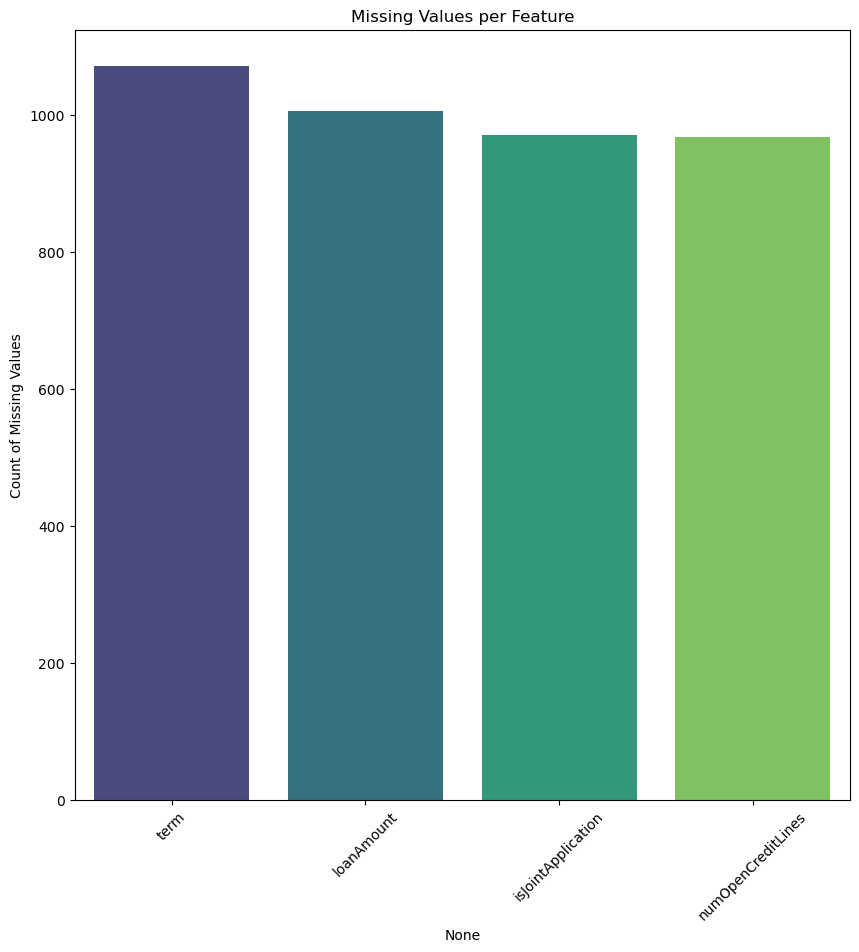

In [25]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,10))
sns.barplot(x=missing.index, y=missing.values, palette="viridis")
plt.title("Missing Values per Feature")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45)
plt.show()

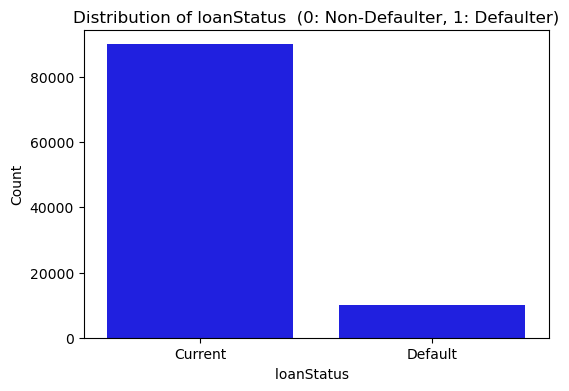

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loanStatus', data=df_loan, color='blue')
plt.title('Distribution of loanStatus  (0: Non-Defaulter, 1: Defaulter)')
plt.xlabel('loanStatus  ')
plt.ylabel('Count')
plt.show()

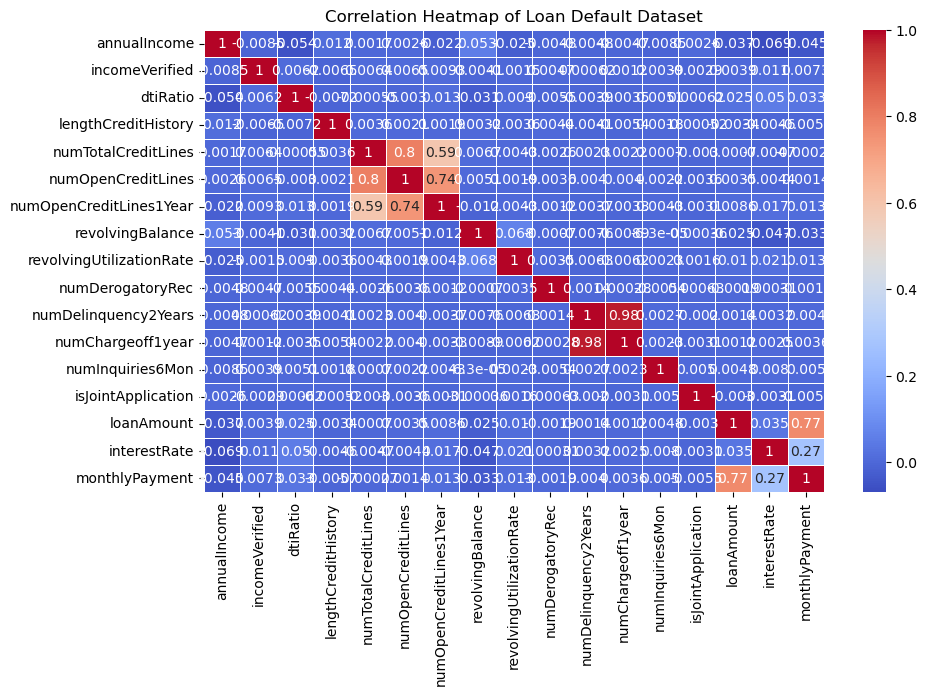

In [32]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Loan Default Dataset")
plt.show()

In [33]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

summary_numeric = df[numeric_cols].describe().T
missing = df.isna().mean().sort_values(ascending=False).rename("missing_ratio")

print("\n Summary Statistics (Numeric)")
display(summary_numeric)

print("\n Missing Value Ratios (Top 20)")
display(missing.head(20))


 Summary Statistics (Numeric)


,count,mean,std,min,25%,50%,75%,max
annualIncome,100000.0,54718.013140,3178.627286,38328.00,52648.00,54781.00,56866.00,69553.00
incomeVerified,100000.0,0.686070,0.464091,0.00,0.00,1.00,1.00,1.00
dtiRatio,100000.0,17.281603,5.100633,0.00,13.82,17.24,20.72,40.51
lengthCreditHistory,100000.0,10.922280,10.673098,1.00,4.00,6.00,15.00,40.00
numTotalCreditLines,100000.0,15.015820,4.007494,1.00,12.00,15.00,18.00,32.00
numOpenCreditLines,99033.0,11.274434,3.770307,1.00,9.00,11.00,14.00,29.00
numOpenCreditLines1Year,100000.0,7.604960,3.407668,1.00,5.00,7.00,10.00,26.00
revolvingBalance,100000.0,14848.970210,2507.838336,4291.00,13150.00,14852.00,16537.25,25802.00
revolvingUtilizationRate,100000.0,65.090856,15.286859,0.00,54.52,65.18,75.57,100.00
numDerogatoryRec,100000.0,0.844460,2.519157,0.00,0.00,0.00,0.00,15.00



 Missing Value Ratios (Top 20)


term                        0.01071
loanAmount                  0.01006
isJointApplication          0.00971
numOpenCreditLines          0.00967
residentialState            0.00000
incomeVerified              0.00000
yearsEmployment             0.00000
annualIncome                0.00000
homeOwnership               0.00000
numTotalCreditLines         0.00000
lengthCreditHistory         0.00000
dtiRatio                    0.00000
numOpenCreditLines1Year     0.00000
numDelinquency2Years        0.00000
revolvingBalance            0.00000
revolvingUtilizationRate    0.00000
numDerogatoryRec            0.00000
date                        0.00000
numInquiries6Mon            0.00000
numChargeoff1year           0.00000
Name: missing_ratio, dtype: float64

In [34]:
# outlier detection and handling 
print("OUTLIER COUNT IN EACH NUMERIC COLUMN")
outliers = {}

for col in numeric_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
  outliers[col] = outlier_count

outliers
     

OUTLIER COUNT IN EACH NUMERIC COLUMN


{'annualIncome': 1014,
 'incomeVerified': 0,
 'dtiRatio': 686,
 'lengthCreditHistory': 8665,
 'numTotalCreditLines': 196,
 'numOpenCreditLines': 852,
 'numOpenCreditLines1Year': 916,
 'revolvingBalance': 638,
 'revolvingUtilizationRate': 315,
 'numDerogatoryRec': 18302,
 'numDelinquency2Years': 15073,
 'numChargeoff1year': 13499,
 'numInquiries6Mon': 11234,
 'isJointApplication': 4968,
 'loanAmount': 850,
 'interestRate': 1057,
 'monthlyPayment': 1138}

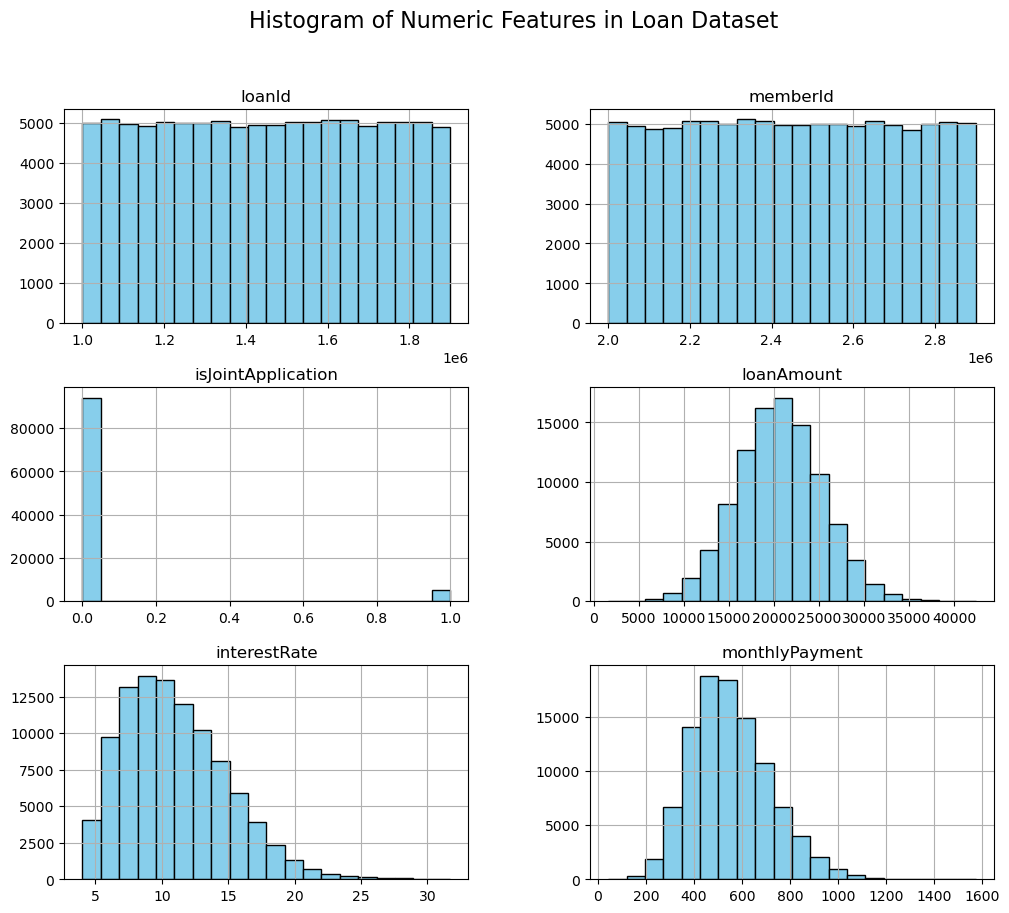

In [41]:
df_loan.hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Histogram of Numeric Features in Loan Dataset', fontsize=16)
plt.show()

In [45]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('loanStatus', axis=1)
y = df['loanStatus']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
   



Shape of X_train: (80000, 24)
Shape of X_test: (20000, 24)
Shape of y_train: (80000,)
Shape of y_test: (20000,)


In [46]:
from sklearn.impute import SimpleImputer

numerical_cols_with_nulls = ['numOpenCreditLines', 'isJointApplication', 'loanAmount']
categorical_cols_with_nulls = ['term']

# Numerical imputer
num_imputer = SimpleImputer(strategy='median')
X_train[numerical_cols_with_nulls] = num_imputer.fit_transform(X_train[numerical_cols_with_nulls])
X_test[numerical_cols_with_nulls] = num_imputer.transform(X_test[numerical_cols_with_nulls])

# Categorical imputer
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols_with_nulls] = cat_imputer.fit_transform(X_train[categorical_cols_with_nulls])
X_test[categorical_cols_with_nulls] = cat_imputer.transform(X_test[categorical_cols_with_nulls])

In [47]:
num_cols = df.select_dtypes(include=[np.number]).columns
print(f"Numerical columns: {list(num_cols)}")
for i in num_cols:
  df[i].fillna(df[i].median(), inplace=True)

Numerical columns: ['annualIncome', 'incomeVerified', 'dtiRatio', 'lengthCreditHistory', 'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year', 'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec', 'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon', 'isJointApplication', 'loanAmount', 'interestRate', 'monthlyPayment']


C:\Users\dell7\AppData\Local\Temp\ipykernel_21796\1370871299.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(), inplace=True)


In [48]:
# Identify categorical no (columns) (dtype='object')
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\nCategorical columns to be encoded: {list(categorical_cols)}")


Categorical columns to be encoded: ['residentialState', 'yearsEmployment', 'homeOwnership', 'date', 'purpose', 'term', 'grade', 'loanStatus']


In [49]:
for i in categorical_cols:
  df[i].fillna(df[i].mode()[0], inplace=True)
print('handled null values')

handled null values


C:\Users\dell7\AppData\Local\Temp\ipykernel_21796\1382049581.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mode()[0], inplace=True)


In [50]:
# Perform one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nShape of the dataframe after one-hot encoding:", df_encoded.shape)
print("First 5 rows of the encoded dataframe:")
print(df_encoded.head(1).T)


Shape of the dataframe after one-hot encoding: (100000, 873)
First 5 rows of the encoded dataframe:
                         0
annualIncome         56471
incomeVerified           1
dtiRatio              16.8
lengthCreditHistory      6
numTotalCreditLines     11
...                    ...
grade_D3             False
grade_E1             False
grade_E2             False
grade_E3              True
loanStatus_Default   False

[873 rows x 1 columns]


In [51]:
df_encoded.shape

(100000, 873)

In [52]:
print(df_encoded.columns)

Index(['annualIncome', 'incomeVerified', 'dtiRatio', 'lengthCreditHistory',
       'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year',
       'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec',
       ...
       'grade_C1', 'grade_C2', 'grade_C3', 'grade_D1', 'grade_D2', 'grade_D3',
       'grade_E1', 'grade_E2', 'grade_E3', 'loanStatus_Default'],
      dtype='object', length=873)


In [67]:
# Import libraries 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [68]:
categorical_cols = df_loan.select_dtypes(include='object').columns
print("Categorical columns:", categorical_cols)
le = LabelEncoder()
for col in categorical_cols:
    if df_loan[col].nunique() == 2:  # Only encode columns with 2 unique values
        df_loan[col] = le.fit_transform(df_loan[col])
df_loan = pd.get_dummies(df_loan, columns=[col for col in categorical_cols if df_loan[col].nunique() > 2], drop_first=True)
print("Shape after encoding:", df_loan.shape)
print(df_loan.head())

Categorical columns: Index([], dtype='object')
Shape after encoding: (100000, 808)
      loanId   memberId  isJointApplication  loanAmount  interestRate  \
0  1888978.0  2305095.0                 0.0     25190.0          6.25   
1  1299695.0  2610493.0                 0.0     21189.0         10.49   
2  1875016.0  2491679.0                 0.0     29908.0          9.11   
3  1440478.0  2092798.0                 0.0     13053.0         11.89   
4  1124634.0  2633077.0                 0.0     24613.0         15.13   

   monthlyPayment  loanStatus  date_1/1/2016  date_1/10/2015  date_1/10/2016  \
0           490.0         0.0          False           False           False   
1           455.0         0.0          False           False           False   
2           622.0         0.0          False           False           False   
3           343.0         0.0          False           False           False   
4           587.0         0.0          False           False           False  

In [78]:
X = df_encoded.drop('annualIncome', axis=1)
y = df_encoded['annualIncome']
print("\nFeatures (X) shape:", X.shape)
print("Target (y) shape:", y.shape)



Features (X) shape: (100000, 872)
Target (y) shape: (100000,)


In [79]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('loanStatus', axis=1)
y = df['loanStatus']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (80000, 24)
Shape of X_test: (20000, 24)
Shape of y_train: (80000,)
Shape of y_test: (20000,)


In [80]:
from sklearn.impute import SimpleImputer

numerical_cols_with_nulls = ['numOpenCreditLines', 'isJointApplication', 'loanAmount']
categorical_cols_with_nulls = ['term']

# Numerical imputer
num_imputer = SimpleImputer(strategy='median')
X_train[numerical_cols_with_nulls] = num_imputer.fit_transform(X_train[numerical_cols_with_nulls])
X_test[numerical_cols_with_nulls] = num_imputer.transform(X_test[numerical_cols_with_nulls])

# Categorical imputer
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols_with_nulls] = cat_imputer.fit_transform(X_train[categorical_cols_with_nulls])
X_test[categorical_cols_with_nulls] = cat_imputer.transform(X_test[categorical_cols_with_nulls])

In [81]:
threshold = 2000

state_counts = X_train['residentialState'].value_counts()

# We create a list of the states that meet our threshold.
top_states = state_counts[state_counts >= threshold].index.tolist()

print(f"Found {len(top_states)} states with counts >= {threshold} in X_train.")
print("These will be kept:", top_states)
print("-" * 30)

print("Applying binning to X_train...")
X_train['residentialState'] = X_train['residentialState'].apply(lambda x: x if x in top_states else 'Other')

print("Applying the same binning rule to X_test...")
X_test['residentialState'] = X_test['residentialState'].apply(lambda x: x if x in top_states else 'Other')



print("\nNew category counts in X_train['residentialState']:")
print(X_train['residentialState'].value_counts())

print("\nNew category counts in X_test['residentialState']:")
print(X_test['residentialState'].value_counts())

Found 10 states with counts >= 2000 in X_train.
These will be kept: ['CA', 'FL', 'DC', 'NY', 'TX', 'WA', 'IA', 'IL', 'IN', 'ID']
------------------------------
Applying binning to X_train...
Applying the same binning rule to X_test...

New category counts in X_train['residentialState']:
residentialState
Other    45951
CA        5597
FL        5257
DC        4292
NY        4125
TX        2760
WA        2758
IA        2395
IL        2376
IN        2246
ID        2243
Name: count, dtype: int64

New category counts in X_test['residentialState']:
residentialState
Other    11390
CA        1460
FL        1346
DC        1104
NY        1036
WA         719
TX         672
ID         602
IA         580
IN         554
IL         537
Name: count, dtype: int64


In [82]:
def engineer_date_features(df):
    """Converts 'date' column to datetime and extracts features."""

    df_copy = df.copy()


    df_copy['date'] = pd.to_datetime(df_copy['date'], format='%m/%d/%Y')

    df_copy['loan_issue_year'] = df_copy['date'].dt.year
    df_copy['loan_issue_month'] = df_copy['date'].dt.month
    df_copy['loan_issue_dayofweek'] = df_copy['date'].dt.dayofweek # Monday=0, Sunday=6

    df_copy = df_copy.drop('date', axis=1)

    return df_copy

In [83]:
#  Apply the function to both X_train and X_test ---
print("Processing date features for X_train...")
X_train = engineer_date_features(X_train)

print("Processing date features for X_test...")
X_test = engineer_date_features(X_test)


print("\nNew date features created. X_train columns:")
print(X_train.columns)
print("\nFirst 5 rows with new features:")
print(X_train[['loan_issue_year', 'loan_issue_month', 'loan_issue_dayofweek']].head())

Processing date features for X_train...
Processing date features for X_test...

New date features created. X_train columns:
Index(['residentialState', 'yearsEmployment', 'homeOwnership', 'annualIncome',
       'incomeVerified', 'dtiRatio', 'lengthCreditHistory',
       'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year',
       'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec',
       'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon',
       'purpose', 'isJointApplication', 'loanAmount', 'term', 'interestRate',
       'monthlyPayment', 'grade', 'loan_issue_year', 'loan_issue_month',
       'loan_issue_dayofweek'],
      dtype='object')

First 5 rows with new features:
       loan_issue_year  loan_issue_month  loan_issue_dayofweek
75220             2015                 1                     0
48955             2014                11                     2
44966             2015                 4                     6
13568             201

In [84]:
# For 'term', we can extract the number directly.
X_train['term'] = X_train['term'].str.replace(' months', '').astype(int)
X_test['term'] = X_test['term'].str.replace(' months', '').astype(int)

employment_map = {
    '< 1 year': 0.5,
    '1 year': 1,
    '2-5 years': 3.5,
    '6-9 years': 7.5,  # Midpoint of 6 and 9
    '10+ years': 10
}
X_train['yearsEmployment'] = X_train['yearsEmployment'].map(employment_map)
X_test['yearsEmployment'] = X_test['yearsEmployment'].map(employment_map)

grade_map = {
    'A1': 0, 'A2': 1, 'A3': 2,
    'B1': 3, 'B2': 4, 'B3': 5,
    'C1': 6, 'C2': 7, 'C3': 8,
    'D1': 9, 'D2': 10, 'D3': 11,
    'E1': 12, 'E2': 13, 'E3': 14
}
X_train['grade'] = X_train['grade'].map(grade_map)
X_test['grade'] = X_test['grade'].map(grade_map)


print("Ordinal encoding complete.")
print("X_train[['term', 'yearsEmployment', 'grade']].head():")
print(X_train[['term', 'yearsEmployment', 'grade']].head())
     

Ordinal encoding complete.
X_train[['term', 'yearsEmployment', 'grade']].head():
       term  yearsEmployment  grade
75220    36              7.5      4
48955    60              0.5      5
44966    60              1.0     13
13568    36             10.0      3
92727    36              3.5      0


In [85]:
from sklearn.preprocessing import OneHotEncoder

# --- Step 1: Identify the nominal columns to encode ---
nominal_cols = ['homeOwnership', 'purpose', 'residentialState']

# --- Step 2: Set up and fit the encoder ---
# handle_unknown='ignore' will prevent errors if a category in test data was not in train data.
# sparse_output=False ensures the output is a standard numpy array.
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit the encoder on the training data and transform it
X_train_ohe_array = ohe.fit_transform(X_train[nominal_cols])

# Transform the test data using the FITTED encoder
X_test_ohe_array = ohe.transform(X_test[nominal_cols])

# Create new DataFrames  ---
ohe_cols = ohe.get_feature_names_out(nominal_cols)

X_train_ohe = pd.DataFrame(X_train_ohe_array, columns=ohe_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe_array, columns=ohe_cols, index=X_test.index)


# --- Step 4: Combine with the main dataframes and drop the original columns ---
# Drop the original nominal columns
X_train = X_train.drop(columns=nominal_cols)
X_test = X_test.drop(columns=nominal_cols)

# Concatenate the new one-hot encoded columns
X_train = pd.concat([X_train, X_train_ohe], axis=1)
X_test = pd.concat([X_test, X_test_ohe], axis=1)

print("\nOne-Hot Encoding complete.")
print(f"Original shape of X_train: {X_train.shape}")
print("Number of columns added:", len(ohe_cols))


One-Hot Encoding complete.
Original shape of X_train: (80000, 44)
Number of columns added: 21


In [86]:
#encoding the Y , as for XGBoost we can't use strings
target_map = {
    'Current': 0,
    'Default': 1
}

# --- Step 2: Apply the mapping to both y_train and y_test ---
print("Encoding y_train...")
y_train = y_train.map(target_map)

print("Encoding y_test...")
y_test = y_test.map(target_map)

# --- Step 3: Verify the result ---
# It's always good practice to check your work.
print("\nVerification of y_train encoding:")
print(y_train.value_counts())

print("\nVerification of y_test encoding:")
print(y_test.value_counts())

Encoding y_train...
Encoding y_test...

Verification of y_train encoding:
loanStatus
0    72035
1     7965
Name: count, dtype: int64

Verification of y_test encoding:
loanStatus
0    17961
1     2039
Name: count, dtype: int64


In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
     

In [88]:
numerical_features = [col for col in X_train.columns if X_train[col].nunique() > 2] # A simple way to get non-binary cols

scaler = StandardScaler()

# Fit on training data ONLY
scaler.fit(X_train[numerical_features])

# Transform both train and test data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("Feature scaling complete.")

Feature scaling complete.


In [89]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier



counts = y_train.value_counts()

scale_pos_weight = counts[0] / counts[1]

print(f"Target variable encoded. Calculated scale_pos_weight: {scale_pos_weight:.2f}\n")
#applyign smot to avoid imbalance
print("Applying SMOTE to the training data...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

models = {
    # --- Models with built-in imbalance handling ---
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss'),

    # --- Models without built-in imbalance handling (we expect lower recall) ---
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
}


for name, model in models.items():
    print(f"--- Training and Evaluating {name} ---")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")

    print(classification_report(y_test, y_pred))
    print("-" * 50 + "\n")
     

Target variable encoded. Calculated scale_pos_weight: 9.04

Applying SMOTE to the training data...
--- Training and Evaluating Logistic Regression ---
Accuracy: 0.8397

Confusion Matrix:
[[15119  2842]
 [  364  1675]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.90     17961
           1       0.37      0.82      0.51      2039

    accuracy                           0.84     20000
   macro avg       0.67      0.83      0.71     20000
weighted avg       0.91      0.84      0.86     20000

--------------------------------------------------

--- Training and Evaluating Random Forest ---
Accuracy: 0.9212

Confusion Matrix:
[[17854   107]
 [ 1470   569]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     17961
           1       0.84      0.28      0.42      2039

    accuracy                           0.92     20000
   macro avg       0.88 

C:\anaconda install\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:07:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8793

Confusion Matrix:
[[16051  1910]
 [  503  1536]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93     17961
           1       0.45      0.75      0.56      2039

    accuracy                           0.88     20000
   macro avg       0.71      0.82      0.75     20000
weighted avg       0.92      0.88      0.89     20000

--------------------------------------------------

--- Training and Evaluating Gradient Boosting ---
Accuracy: 0.9309

Confusion Matrix:
[[17722   239]
 [ 1143   896]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     17961
           1       0.79      0.44      0.56      2039

    accuracy                           0.93     20000
   macro avg       0.86      0.71      0.76     20000
weighted avg       0.92      0.93      0.92     20000

--------------------------------------------------

--- Traini